Εκκίνηση Spark Session...
Φόρτωση δεδομένων (heart.csv)...

Εκπαίδευση Logistic Regression...
Εκπαίδευση Random Forest...
----------------------------------------
Accuracy Logistic Regression: 83.89%
Accuracy Random Forest:     84.56%
----------------------------------------


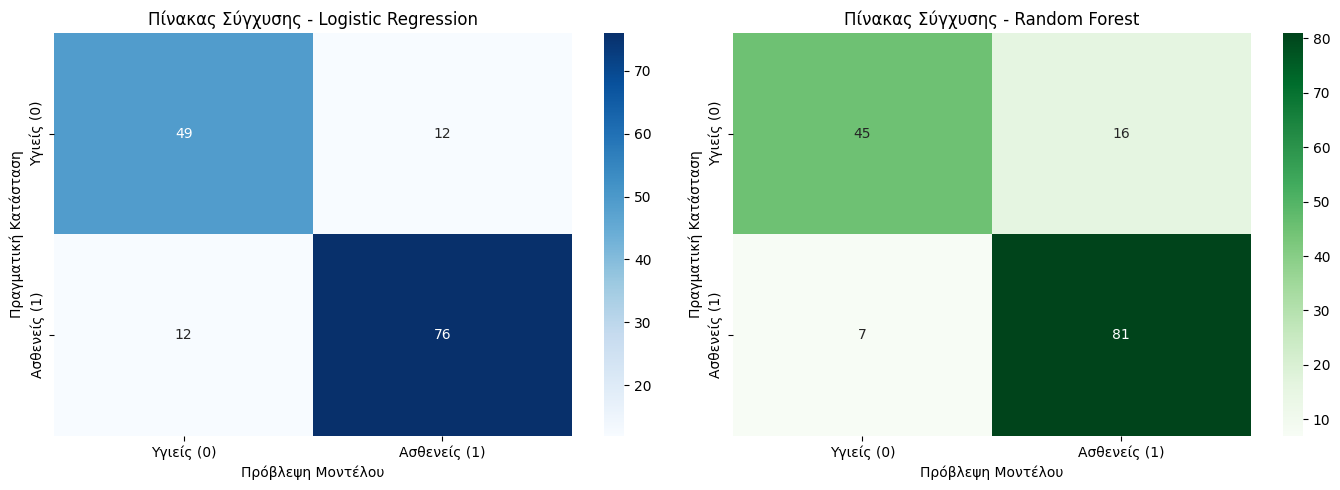

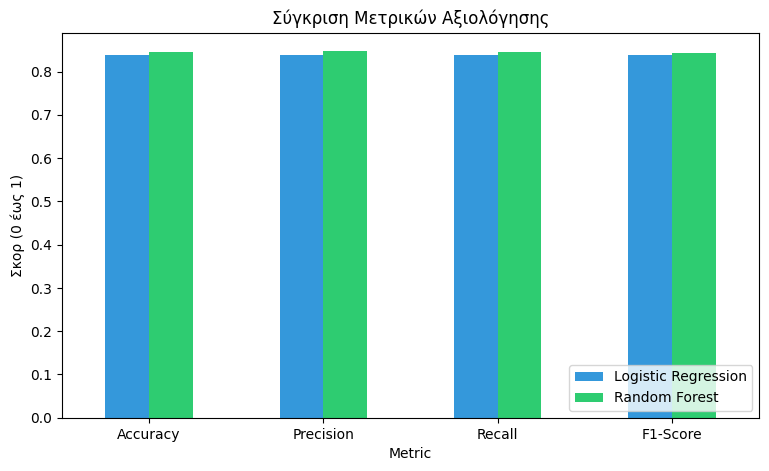

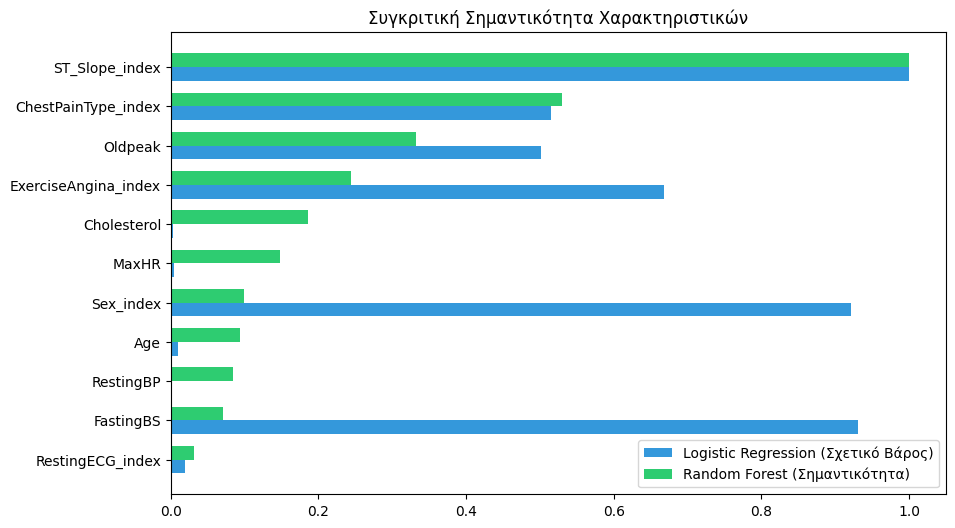

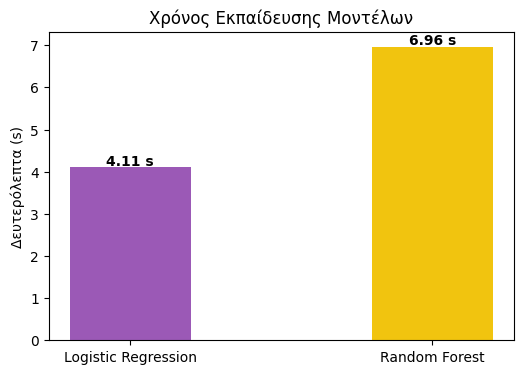

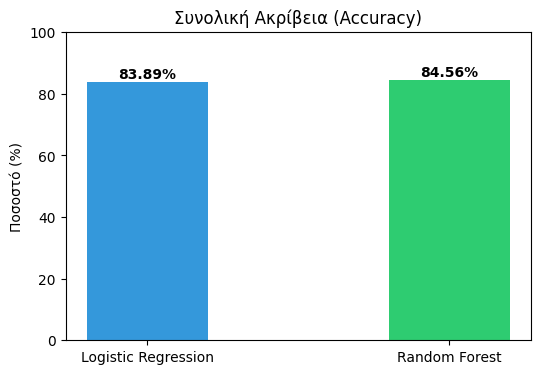

In [ ]:
# Εξαμηνιαία Εργασία - PySpark Classification

#1. Εισαγωγή Βιβλιοθηκών
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

#2. Αρχικοποίηση Spark & Φόρτωση Δεδομένων
print("Εκκίνηση Spark Session...")
spark = SparkSession.builder.appName("HeartDiseaseClassification").getOrCreate()

print("Φόρτωση δεδομένων (heart.csv)...")
df = spark.read.csv("heart.csv", header=True, inferSchema=True)

#3. Προετοιμασία Δεδομένων (Preprocessing)
target_column = 'HeartDisease'
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numeric_columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# Μετατροπή κειμένου σε αριθμούς
indexers = [StringIndexer(inputCol=col, outputCol=col+"_index") for col in categorical_columns]

# Συγχώνευση χαρακτηριστικών
assembler_inputs = numeric_columns + [col+"_index" for col in categorical_columns]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# Διαχωρισμός 80-20
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

#4. Ορισμός Μοντέλων & Pipelines
lr = LogisticRegression(featuresCol="features", labelCol=target_column)
rf = RandomForestClassifier(featuresCol="features", labelCol=target_column, numTrees=100, seed=42)

pipeline_lr = Pipeline(stages=indexers + [assembler, lr])
pipeline_rf = Pipeline(stages=indexers + [assembler, rf])

#5. Εκπαίδευση (Χρονομετρημένη)
print("\nΕκπαίδευση Logistic Regression...")
start_time = time.time()
model_lr = pipeline_lr.fit(train_data)
time_lr = time.time() - start_time

print("Εκπαίδευση Random Forest...")
start_time = time.time()
model_rf = pipeline_rf.fit(train_data)
time_rf = time.time() - start_time

#6. Προβλέψεις & Αξιολόγηση Μετρικών
predictions_lr = model_lr.transform(test_data)
predictions_rf = model_rf.transform(test_data)

eval_acc = MulticlassClassificationEvaluator(labelCol=target_column, predictionCol="prediction", metricName="accuracy")
eval_prec = MulticlassClassificationEvaluator(labelCol=target_column, metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol=target_column, metricName="weightedRecall")
eval_f1 = MulticlassClassificationEvaluator(labelCol=target_column, metricName="f1")

acc_lr = eval_acc.evaluate(predictions_lr)
acc_rf = eval_acc.evaluate(predictions_rf)

print("-" * 40)
print(f"Accuracy Logistic Regression: {acc_lr * 100:.2f}%")
print(f"Accuracy Random Forest:     {acc_rf * 100:.2f}%")
print("-" * 40)

# ΔΗΜΙΟΥΡΓΙΑ ΓΡΑΦΗΜΑΤΩΝ (VISUALIZATIONS)

#1. ΠΙΝΑΚΕΣ ΣΥΓΧΥΣΗΣ
y_true_lr = predictions_lr.select(target_column).toPandas()
y_pred_lr = predictions_lr.select("prediction").toPandas()
cm_lr = confusion_matrix(y_true_lr, y_pred_lr)

y_true_rf = predictions_rf.select(target_column).toPandas()
y_pred_rf = predictions_rf.select("prediction").toPandas()
cm_rf = confusion_matrix(y_true_rf, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Υγιείς (0)', 'Ασθενείς (1)'], yticklabels=['Υγιείς (0)', 'Ασθενείς (1)'], ax=axes[0])
axes[0].set_title('Πίνακας Σύγχυσης - Logistic Regression')
axes[0].set_ylabel('Πραγματική Κατάσταση')
axes[0].set_xlabel('Πρόβλεψη Μοντέλου')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Υγιείς (0)', 'Ασθενείς (1)'], yticklabels=['Υγιείς (0)', 'Ασθενείς (1)'], ax=axes[1])
axes[1].set_title('Πίνακας Σύγχυσης - Random Forest')
axes[1].set_ylabel('Πραγματική Κατάσταση')
axes[1].set_xlabel('Πρόβλεψη Μοντέλου')
plt.tight_layout()
plt.show()

#2. ΣΥΓΚΡΙΣΗ ΜΕΤΡΙΚΩΝ
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [acc_lr, eval_prec.evaluate(predictions_lr), eval_rec.evaluate(predictions_lr), eval_f1.evaluate(predictions_lr)],
    'Random Forest': [acc_rf, eval_prec.evaluate(predictions_rf), eval_rec.evaluate(predictions_rf), eval_f1.evaluate(predictions_rf)]
}
df_metrics = pd.DataFrame(metrics_data)
df_metrics.set_index('Metric').plot(kind='bar', figsize=(9, 5), color=['#3498db', '#2ecc71'])
plt.title('Σύγκριση Μετρικών Αξιολόγησης')
plt.ylabel('Σκορ (0 έως 1)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

#3. ΣΗΜΑΝΤΙΚΟΤΗΤΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ
rf_model_stage = model_rf.stages[-1]
importances = rf_model_stage.featureImportances.toArray()

lr_model_stage = model_lr.stages[-1]
lr_coeffs = lr_model_stage.coefficients.toArray()

df_features = pd.DataFrame({'Feature': assembler_inputs, 'RF_Importance': importances, 'LR_Absolute_Weight': np.abs(lr_coeffs)})
df_features['RF_Importance'] = df_features['RF_Importance'] / df_features['RF_Importance'].max()
df_features['LR_Absolute_Weight'] = df_features['LR_Absolute_Weight'] / df_features['LR_Absolute_Weight'].max()
df_features = df_features.sort_values(by='RF_Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_indices = np.arange(len(df_features))
width = 0.35
ax.barh(y_indices - width/2, df_features['LR_Absolute_Weight'], width, label='Logistic Regression (Σχετικό Βάρος)', color='#3498db')
ax.barh(y_indices + width/2, df_features['RF_Importance'], width, label='Random Forest (Σημαντικότητα)', color='#2ecc71')
ax.set_yticks(y_indices)
ax.set_yticklabels(df_features['Feature'])
ax.set_title('Συγκριτική Σημαντικότητα Χαρακτηριστικών')
ax.legend()
plt.show()

#4. ΧΡΟΝΟΣ ΕΚΠΑΙΔΕΥΣΗΣ
plt.figure(figsize=(6, 4))
plt.bar(['Logistic Regression', 'Random Forest'], [time_lr, time_rf], color=['#9b59b6', '#f1c40f'], width=0.4)
plt.title('Χρόνος Εκπαίδευσης Μοντέλων')
plt.ylabel('Δευτερόλεπτα (s)')
for i, v in enumerate([time_lr, time_rf]):
    plt.text(i, v + 0.05, f"{v:.2f} s", ha='center', fontweight='bold')
plt.show()

#5. ΣΥΓΚΡΙΣΗ ΑΚΡΙΒΕΙΑΣ (ACCURACY) - BAR CHART
plt.figure(figsize=(6, 4))
plt.bar(['Logistic Regression', 'Random Forest'], [acc_lr * 100, acc_rf * 100], color=['#3498db', '#2ecc71'], width=0.4)
plt.title('Συνολική Ακρίβεια (Accuracy)')
plt.ylabel('Ποσοστό (%)')
plt.ylim(0, 100)
for i, v in enumerate([acc_lr * 100, acc_rf * 100]):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()